# 解答例（教員用）　第12回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`___`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第12回　不均衡データと ROC
***
> **前提**: 第6回の評価指標を発展させ，クラス不均衡への対処と ROC/PR 曲線を学びます。第8回問題4で触れた Precision / Recall / F1 も本回で実践します。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや閾値を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
> | **【指示書】** | 知識を LLM に渡す | 実験で得た知識を、LLM が使える「指示書」に書き起こし、LLM の出力を自分のログで採点する |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="threshold", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データ内で作った予測 = 交差検証の予測）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. 不均衡データの生成
2. class_weight
3. ROC 曲線と AUC
4. 適合率-再現率曲線
5. 実験で得た知識を LLM への指示書にする【指示書】

---

## この回で学ぶこと

### クラス不均衡が問題になる場面

現実の分類問題では，クラスの数が極端に偏っていることが多い：

| 問題 | クラス比率 |
|---|---|
| クレジットカード不正検知 | 正常 99.8% / 不正 0.2% |
| 医療診断（稀な疾患） | 陰性 99% / 陽性 1% |
| 製品不良品検出 | 良品 99% / 不良品 1% |

このような状況で「全部多数クラスと予測」すると正解率 99.8% になるが，**不正を一件も検知できていない**ので全く役に立たないモデルだ。

### 混同行列（Confusion Matrix）の理解

混同行列は分類モデルの結果を4つの分類で整理する：

```
                予測: Negative  予測: Positive
実際: Negative      TN               FP
実際: Positive      FN               TP
```

- **TP（True Positive）**: 陽性を陽性と正しく予測
- **TN（True Negative）**: 陰性を陰性と正しく予測
- **FP（False Positive）**: 陰性を陽性と誤予測（偽陽性）→ 「誤報」
- **FN（False Negative）**: 陽性を陰性と誤予測（偽陰性）→ 「見逃し」

### 各評価指標の意味

- **適合率（Precision）** = TP / (TP + FP)：「陽性と予測したうち実際に陽性の割合」→ **誤報を減らしたい**時に重視
- **再現率（Recall）** = TP / (TP + FN)：「実際の陽性のうち正しく予測した割合」→ **見逃しを減らしたい**時に重視（医療では特に重要）
- **F1スコア** = 2 × Precision × Recall / (Precision + Recall)：両者の調和平均

### ROC 曲線と AUC

ROC 曲線は**分類閾値を 0〜1 で変化させた時**の「偽陽性率（FPR）vs 真陽性率（TPR）」をプロットしたものだ。

- 完璧なモデル：左上の角に近い曲線
- ランダムな予測：対角線（AUC = 0.5）
- **AUC（Area Under the Curve）**：ROC 曲線の下の面積（0〜1）。1に近いほど良い

### PR 曲線が重要な場面

不均衡データでは ROC 曲線が「楽観的に見える」場合がある（TN が多いため FPR が小さくなりやすい）。**適合率-再現率曲線（PR曲線）** は少数クラスに注目した評価に向いている。

> **卒業研究での指針**: 不均衡データを扱う場合は，正解率だけでなく F1スコア，AUC，PR-AUC を報告することが学術的に求められる。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学 | 稀な疾患のスクリーニング，がんの早期発見（陽性が1〜5%） |
| 金融 | クレジット不正，マネーロンダリング検知（正常が99%超） |
| 製造・品質管理 | 不良品検出，設備故障の予兆検知 |
| 情報セキュリティ | 侵入検知，マルウェア分類 |
| 社会科学 | 選挙での少数派支持予測，希少イベントの分析 |

### 応用できる場面

- **少数クラスを見逃すコストが高い**（医療の見逃し，不正の未検知）
- **誤報のコストと見逃しのコストが非対称**（用途によって Precision / Recall の重みが変わる）
- クラス比率が **1:10 以上**に偏っている
- 分類**閾値を業務要件に合わせて調整**したい

### 応用しにくい・向かない場面

- **クラスがほぼ均衡**している → Accuracy でも十分なことが多い
- **回帰問題**（連続値予測）— 本回の指標は分類専用
- **全クラスが同等に重要なマルチクラス分類**（1対多の不均衡対策だけでは不十分）
- ROC-AUC だけを報告して満足する場合（**極端な不均衡では PR 曲線の方が実態を反映**しやすい）
- `class_weight` や SMOTE を適用したら**必ず良くなるとは限らない**— 検証が必要

### 研究で報告するときのポイント

1. **クラス比率**を表で明示する
2. Accuracy に加え **F1，ROC-AUC，PR-AUC（Average Precision）** を併記
3. 採用した**閾値**とその理由（「Recall を 0.9 以上にした」など）
4. 混同行列で **FN（見逃し）と FP（誤報）** のトレードオフを議論

### 関連する発展トピック（調べてみると良い）

- SMOTE，ADASYN（オーバーサンプリング）
- Cost-sensitive learning（誤分類コストの重み付け）
- Calibration（確率出力の信頼性）— 第17回の Overconfidence と関連

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV）」だけを記録する。テストデータは final_test() で1回だけ。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        import numpy as np
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if len(nums) == len(vals) and len(set(nums)) > 2:
                edge = k != "seed" and b["params"][k] in (min(nums), max(nums))
                line += f"（範囲 {min(nums):g}〜{max(nums):g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"最終テストスコア = {self.test_result:.4f}   （検証ベスト = {self.best()['score']:.4f}）")
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


## 問題1　不均衡データの生成と確認　【骨格+選択】
***

### `make_classification` のパラメータ解説

`make_classification` は人工的な分類データを生成する。今回のパラメータ：
- `n_samples=5000`：5000件のデータ
- `n_features=20`：20個の特徴量（うち役に立つのは `n_informative=5` 個、`n_redundant=2` 個は他の特徴量の組合せ、残りはノイズ）
- `class_sep=0.7`：クラスの分離しやすさ（**大きいほど分けやすい**。小さいと重なりが増え、見逃しが起きやすい現実に近いデータになる）
- `weights=[0.95, 0.05]`：**クラス0が95%，クラス1が5%** という不均衡設定
- `random_state=0`：再現性のため固定

### 不均衡度の確認が最初のステップ

データを受け取ったら，まず**クラスの分布を確認**することが重要だ。不均衡比率によって対処法が変わる：
- 5:1 程度：`class_weight="balanced"` で対処可能（今回）
- 100:1 以上：オーバーサンプリング（SMOTE）やアンダーサンプリングが必要

### 課題

下のコードセルは、不均衡データの生成とクラス分布の表示を用意してありますが、**核心（train/test 分割）はあなたが書きます**（`# ★あなたが書く★`）。まずは `minority_ratio = 0.05` のまま実行し、どれだけ偏ったデータかを確認してください。`minority_ratio`・`class_sep`（★印の行）を変えれば不均衡の度合いや分けやすさを変えられます（`class_sep` を大きくしすぎると、どんな設定でも見逃しがほぼ出ず、問題2の実験の差が見えなくなります）。

ここで生成したデータ（`X_train, X_test, y_train, y_test`）は問題2以降でそのまま使います。

そのうえで、次の **設計判断** に答えてください。

> **設計判断（不均衡への対処を選ぶ）**: このデータで「**陽性（クラス1＝不正/疾患など）の見逃し（FN）を絶対に減らしたい**」という状況だとします。次の対処から**1つ選び、理由**を解答用コードセルに書いてください。選んだ方針は問題2の実験につながります。
>
> - **(A) 何もしない**（そのまま `LogisticRegression` を学習）
> - **(B) `class_weight="balanced"`** … 少数クラスの誤分類のペナルティを大きくする
> - **(C) 決定閾値を下げる** … `predict_proba` のしきい値を 0.5 より小さくして陽性判定を増やす
> - **(D) オーバーサンプリング（SMOTE 等）** … 少数クラスを人工的に増やしてクラス比を是正
> - **(E) アンダーサンプリング** … 多数クラスを間引いてクラス比を是正
> - **(F) 決定閾値を上げる（0.5→0.7）** … 陽性判定を厳しくする
>
> ヒント：「見逃しを減らしたい＝Recall を上げたい」とき、どの対処が直接効くでしょうか。逆効果になる選択肢も混ざっています（例えば (F) は見逃しを増やす方向です）。**やみくもに全部やる**のではなく、**この状況に合うもの**を選び、なぜ効くと思うかを書いてください（複数挙げてもよいが主役を1つ）。


In [2]:
# === 完成済みコード：実行して不均衡の度合いを確認してください ===
# === ★ここを変えて実験する★：少数クラス（クラス1）の比率（まずは 0.05 のまま実行）===
minority_ratio = 0.05
# === ★ここも変えられる★：クラスの分離しやすさ（小さいほど難しい。0.5〜1.5 程度で試せる）===
CLASS_SEP = 0.7

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    class_sep=CLASS_SEP,
    weights=[1 - minority_ratio, minority_ratio],
    random_state=0,
)
# ★あなたが書く★：X, y を train/test に 8:2 で分割する（1行。stratify=y で不均衡比率を保つ）
#   ヒント: train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

counts = pd.Series(y_train).value_counts().sort_index()
ratio = (counts / counts.sum() * 100).round(1)
dist = pd.concat([counts.rename("件数"), ratio.rename("比率%")], axis=1)
dist.index.name = "クラス"
print("訓練データのクラス分布:")
print(dist)


訓練データのクラス分布:
       件数   比率%
クラス            
0    3779  94.5
1     221   5.5


In [3]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
print("X_train の形:", X_train.shape, "（件数, 特徴量数）")
print("先頭 3 件の最初の 5 特徴量:")
print(pd.DataFrame(X_train[:3, :5]).round(2))
print("先頭 30 件のラベル y_train:", y_train[:30], "  ← 1 が少数クラス（陽性）")

X_train の形: (4000, 20) （件数, 特徴量数）
先頭 3 件の最初の 5 特徴量:
      0     1     2     3     4
0  2.07 -1.04 -0.40  0.28 -0.15
1 -0.60  0.15  1.59 -0.87 -0.33
2 -0.59  0.32  0.54 -1.07  0.40
先頭 30 件のラベル y_train: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]   ← 1 が少数クラス（陽性）


In [4]:
# === ✍️ 問題1 解答（採点対象）===

# (1-a) 観察：訓練データのクラス0／クラス1の件数と比率
observation_1_a = """
訓練データ 4000 件：クラス0 = 3779 件（94.5%）、クラス1 = 221 件（5.5%）。約 17 : 1 の不均衡。「全部クラス0と予測」するだけで正解率 0.945 になる。
"""

# (1-b) 設計判断：見逃し（FN）を減らしたい状況で選んだ対処（A〜F）：(　)
# (A) 何もしない（そのまま LogisticRegression を学習）
# (B) class_weight="balanced"（少数クラスの誤分類のペナルティを大きくする）
# (C) 決定閾値を下げる（陽性判定を増やす）
# (D) オーバーサンプリング（SMOTE 等）
# (E) アンダーサンプリング（多数クラスを間引く）
# (F) 決定閾値を上げる（0.5→0.7）
design1_choice = "C"
# (1-c) その理由（なぜこの状況に合うか／なぜ見逃しを減らせると思うか）
answer_1_c = """
(C) 決定閾値を下げる。見逃し（FN）を減らす＝Recall を上げたいので、陽性の確率が 0.5 未満でも陽性と判定する範囲を広げるのが最も直接的で、モデルの再学習も要らない。(F) 閾値を上げるのは逆効果、(A) 何もしないのは見逃しが多い。(B) class_weight も Recall を上げる方向に働くが、係数自体が変わる分、効果が閾値ほど直接でない。(D)(E) のサンプリングは 17 : 1 程度なら過剰。まず閾値で試し、足りなければ (B) を併用しようと考えた。
"""



## 問題2　「見逃しを減らす」最適設定を自分で探す　【探索】
***

### 課題設定：目的を「制約つきの最適化」に翻訳する

問題1で「陽性の見逃し（FN）を減らしたい」と考えました。でも「見逃しを減らす」だけなら **全員を陽性と予測すれば見逃しゼロ**です（Precision は最悪）。現実の依頼は次のような形になります：

> **Recall（見逃さない割合）が 0.80 以上という条件を満たしたうえで、Precision（陽性と言った中の的中率）を最大にする設定を見つけよ。**

この「制約つきの目的」を数値にしたのが下の `objective`（探索の物差し）です。

```
objective = Precision   （Recall ≥ 0.80 のとき）
          = Recall - 0.80（Recall < 0.80 のとき。負の値＝制約違反）
```

### 探す軸

| 軸 | 意味 | 注意点 |
|---|---|---|
| `pos_weight` | クラス1（陽性）の誤りを何倍重く扱うか（1=何もしない）。`class_weight="balanced"` は**この場合およそ 19** に相当 | 大きいほど陽性を見逃しにくいが Precision が落ちる |
| `threshold` | 決定閾値（`proba >= threshold` で陽性）。標準は 0.5 | 下げると陽性判定が増える |
| `C` | 正則化の強さ（大きいほど弱い）。第9回の内容 | 影響は小さいかもしれない。**確かめるのも探索** |

`pos_weight` を上げる方法と `threshold` を下げる方法は、**似た効果**があるでしょうか？ それとも違うでしょうか？ 実験で確かめてください。

### 検証の作法

探索では訓練データ内で「交差検証の予測」（`cross_val_predict`）を作って評価します。テストデータ（`X_test`）は最終評価の **1回だけ**。

### 課題

1. **【実験前に先に書く】** 下の予測セルに、`pos_weight` と `threshold` のどちらが効くか、最良設定の予測と理由を書く。
2. 探索セルの `hypothesis` と `settings` を書き換えて何度も実行（**15回以上**）。**核心2つ（OOF 確率の作成・閾値での 0/1 化）はあなたが書きます**。
3. 経過確認セルで、制約（Recall≥0.80）を満たす設定の中で頭打ち・端に張り付いていないかを見る。
4. 最終評価セルを **1回だけ**実行する。
5. 解答セルに書く。

> **考察1**: 何もしない設定（`pos_weight=1, threshold=0.5`）の Recall と FN 件数は？ そこから何を変えると Recall が上がり、Precision はどう動きましたか？
>
> **考察2（トレードオフ）**: なぜ Recall を上げると Precision が下がるのか、混同行列の TP・FP・FN の動きに触れて説明してください。
>
> **考察3（重みと閾値）**: `pos_weight` を上げる方法と `threshold` を下げる方法で、同じ Recall のときの Precision はどちらが高かったですか？ 差は意味のある大きさでしたか？
>
> **考察4**: 問題1で選んだ対処は、この目的（Recall≥0.80 で Precision 最大）に対して最良でしたか？

In [5]:
# === ✍️ 問題2-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 目的（Recall>=0.80 で Precision 最大）に、より効くと思うのはどちらか（"pos_weight" / "threshold" / "ほぼ同じ"）
prediction_2_which = "threshold"
# 最良だと思う (pos_weight, threshold)
prediction_2_best = (5, 0.2)
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
閾値を下げる方が直接 Recall に効き、class_weight は間接的だと考えた。陽性が 5% なので 0.5 のままでは確率がほとんど 0.5 を超えず、Recall 0.8 には閾値 0.2 前後が必要だと予想した。C の影響はほとんど無いと思った。
"""

In [6]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
# 問題1 で作った X_train / X_test / y_train / y_test を使う。X_test は最終評価まで一切使わない
RECALL_TARGET = 0.80
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
lab = Lab("q12_imbalance", score_name="objective")
_proba_cache = {}                       # (pos_weight, C) ごとの OOF 確率。閾値だけ変える試行は再計算しない

def objective(prec, rec):
    """Recall が目標を満たせば Precision、満たさなければ（負の）不足分"""
    return prec if rec >= RECALL_TARGET else rec - RECALL_TARGET

def oof_proba(pos_weight, C):
    key = (pos_weight, C)
    if key not in _proba_cache:
        model = LogisticRegression(max_iter=1000, C=C, class_weight={0: 1, 1: pos_weight})
        # ★あなたが書く★：訓練データ内の5分割CVで、各サンプルの「陽性の確率」を求めて返す（1行）
        #   ヒント: cross_val_predict(model, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]
        _proba_cache[key] = cross_val_predict(model, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]
    return _proba_cache[key]

def run_trial(hypothesis, pos_weight, threshold, C):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"pos_weight": pos_weight, "threshold": threshold, "C": C}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    proba = oof_proba(pos_weight, C)
    # ★あなたが書く★：予測確率 proba を閾値 threshold で 0/1 に変換して y_pred を作る（1行）
    #   ヒント: (proba >= threshold).astype(int)
    y_pred = (proba >= threshold).astype(int)
    prec = precision_score(y_train, y_pred, zero_division=0)
    rec = recall_score(y_train, y_pred, zero_division=0)
    lab.log(hypothesis, params, objective(prec, rec),
            precision=round(prec, 3), recall=round(rec, 3),
            fn=int(confusion_matrix(y_train, y_pred)[1, 0]))

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (pos_weight, threshold, C)
#       pos_weight … 陽性（クラス1）の誤りを何倍重く扱うか。1 = 何もしない。class_weight="balanced" は陰性:陽性の比（約 17）に相当
#       threshold … 決定閾値。予測確率がこの値以上なら陽性と判定（標準は 0.5、下げると陽性が増える）
#       C … 正則化の強さの逆数（0.01〜100）
#     行を足す／消す／数値を書き換えてよい。例：settings = [(1, 0.5, 1.0), (1, 0.2, 1.0), (1, 0.1, 1.0), (5, 0.5, 1.0), (19, 0.5, 1.0)]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。pos_weight と threshold の両方を動かすこと。
# 進め方の例： ①pos_weight と threshold を別々に動かす → ②制約を満たす所を絞り込む → ③組合せ・C を確認
hypothesis = "何もしない設定を基準に、pos_weight だけ / threshold だけを動かして効き方を比べる"
settings = [                       # (pos_weight, threshold, C)
    (1, 0.5, 1.0),                 # 何もしない（基準）
    (1, 0.2, 1.0), (1, 0.1, 1.0),  # threshold だけ下げる
    (5, 0.5, 1.0), (19, 0.5, 1.0), # pos_weight だけ上げる
]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #01 {'pos_weight': 1, 'threshold': 0.5, 'C': 1.0}  objective=-0.4833  precision=0.787  recall=0.317  fn=151  ★ベスト更新
  #02 {'pos_weight': 1, 'threshold': 0.2, 'C': 1.0}  objective=-0.2842  precision=0.491  recall=0.516  fn=107  ★ベスト更新
  #03 {'pos_weight': 1, 'threshold': 0.1, 'C': 1.0}  objective=-0.1394  precision=0.319  recall=0.661  fn=75  ★ベスト更新
  #04 {'pos_weight': 5, 'threshold': 0.5, 'C': 1.0}  objective=-0.2796  precision=0.458  recall=0.52  fn=106
  #05 {'pos_weight': 19, 'threshold': 0.5, 'C': 1.0}  objective=-0.0398  precision=0.179  recall=0.76  fn=53  ★ベスト更新


In [7]:
hypothesis = "C（正則化の強さ）は結果に影響するか。強い/弱い正則化で比べる"
settings = [(1, 0.5, 0.01), (19, 0.5, 0.01), (19, 0.5, 100), (1, 0.1, 0.01)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #06 {'pos_weight': 1, 'threshold': 0.5, 'C': 0.01}  objective=-0.6914  precision=0.923  recall=0.109  fn=197
  #07 {'pos_weight': 19, 'threshold': 0.5, 'C': 0.01}  objective=-0.0308  precision=0.185  recall=0.769  fn=51  ★ベスト更新
  #08 {'pos_weight': 19, 'threshold': 0.5, 'C': 100}  objective=-0.0398  precision=0.179  recall=0.76  fn=53
  #09 {'pos_weight': 1, 'threshold': 0.1, 'C': 0.01}  objective=-0.1846  precision=0.371  recall=0.615  fn=85


In [8]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

制約（Recall>=0.80）を満たした設定の数: 0 / 9
   trial  pos_weight  threshold       C  objective  precision  recall   fn
6      7          19        0.5    0.01    -0.0308      0.185   0.769   51
4      5          19        0.5    1.00    -0.0398      0.179   0.760   53
7      8          19        0.5  100.00    -0.0398      0.179   0.760   53
2      3           1        0.1    1.00    -0.1394      0.319   0.661   75
8      9           1        0.1    0.01    -0.1846      0.371   0.615   85
3      4           5        0.5    1.00    -0.2796      0.458   0.520  106
1      2           1        0.2    1.00    -0.2842      0.491   0.516  107
0      1           1        0.5    1.00    -0.4833      0.787   0.317  151
■ 試行回数: 9（目安 15 回以上） → まだ足りない
■ ベスト: trial#7 {'pos_weight': 19, 'threshold': 0.5, 'C': 0.01}  objective=-0.0308
■ pos_weight: 3 種類を試した（範囲 1〜19） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ threshold: 3 種類を試した（範囲 0.1〜0.5） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ C: 3 種類を試した（範囲 0.01〜100） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ 仮説を書

In [9]:
hypothesis = "制約 Recall>=0.8 の境界付近を、重みと閾値の組合せで細かく探す"
settings = [(3, 0.3, 1.0), (5, 0.3, 1.0), (5, 0.2, 1.0), (10, 0.5, 1.0), (10, 0.3, 1.0), (19, 0.3, 1.0)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #10 {'pos_weight': 3, 'threshold': 0.3, 'C': 1.0}  objective=-0.2118  precision=0.371  recall=0.588  fn=91
  #11 {'pos_weight': 5, 'threshold': 0.3, 'C': 1.0}  objective=-0.0986  precision=0.266  recall=0.701  fn=66
  #12 {'pos_weight': 5, 'threshold': 0.2, 'C': 1.0}  objective=-0.0127  precision=0.18  recall=0.787  fn=47  ★ベスト更新
  #13 {'pos_weight': 10, 'threshold': 0.5, 'C': 1.0}  objective=-0.1348  precision=0.292  recall=0.665  fn=74
  #14 {'pos_weight': 10, 'threshold': 0.3, 'C': 1.0}  objective=-0.0036  precision=0.157  recall=0.796  fn=45  ★ベスト更新
  #15 {'pos_weight': 19, 'threshold': 0.3, 'C': 1.0}  objective=0.1014  precision=0.101  recall=0.873  fn=28  ★ベスト更新


In [10]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

制約（Recall>=0.80）を満たした設定の数: 1 / 15
    trial  pos_weight  threshold       C  objective  precision  recall  fn
14     15          19        0.3    1.00     0.1014      0.101   0.873  28
13     14          10        0.3    1.00    -0.0036      0.157   0.796  45
11     12           5        0.2    1.00    -0.0127      0.180   0.787  47
6       7          19        0.5    0.01    -0.0308      0.185   0.769  51
4       5          19        0.5    1.00    -0.0398      0.179   0.760  53
7       8          19        0.5  100.00    -0.0398      0.179   0.760  53
10     11           5        0.3    1.00    -0.0986      0.266   0.701  66
12     13          10        0.5    1.00    -0.1348      0.292   0.665  74
■ 試行回数: 15（目安 15 回以上） → OK
■ ベスト: trial#15 {'pos_weight': 19, 'threshold': 0.3, 'C': 1.0}  objective=0.1014
■ pos_weight: 5 種類を試した（範囲 1〜19） ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう
■ threshold: 4 種類を試した（範囲 0.1〜0.5）
■ C: 3 種類を試した（範囲 0.01〜100）
■ 仮説を書いた試行: 15/15
■ 前半の最高 -0.0398 → 後半の最高 0.1014


In [11]:
hypothesis = "重みを大きく・閾値を高くする方向（Recall を確保しつつ Precision を上げられるか）"
settings = [(19, 0.7, 1.0), (40, 0.5, 1.0), (40, 0.7, 1.0), (10, 0.15, 1.0), (10, 0.2, 1.0)]
for w, th, C in settings:
    run_trial(hypothesis, w, th, C)

  #16 {'pos_weight': 19, 'threshold': 0.7, 'C': 1.0}  objective=-0.1982  precision=0.318  recall=0.602  fn=88
  #17 {'pos_weight': 40, 'threshold': 0.5, 'C': 1.0}  objective=0.1046  precision=0.105  recall=0.855  fn=32  ★ベスト更新
  #18 {'pos_weight': 40, 'threshold': 0.7, 'C': 1.0}  objective=-0.0534  precision=0.188  recall=0.747  fn=56
  #19 {'pos_weight': 10, 'threshold': 0.15, 'C': 1.0}  objective=0.0912  precision=0.091  recall=0.887  fn=25
  #20 {'pos_weight': 10, 'threshold': 0.2, 'C': 1.0}  objective=0.1092  precision=0.109  recall=0.855  fn=32  ★ベスト更新


In [12]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
d = lab.df()
print("制約（Recall>=%.2f）を満たした設定の数: %d / %d" % (RECALL_TARGET, (d["recall"] >= RECALL_TARGET).sum(), len(d)))
display(d.drop(columns="hypothesis").sort_values("objective", ascending=False).head(8))
lab.plot(x="threshold", group="pos_weight", logx=False)    # threshold と objective、ベスト更新の推移
lab.report(min_trials=15)

制約（Recall>=0.80）を満たした設定の数: 4 / 20
    trial  pos_weight  threshold     C  objective  precision  recall  fn
19     20          10       0.20  1.00     0.1092      0.109   0.855  32
16     17          40       0.50  1.00     0.1046      0.105   0.855  32
14     15          19       0.30  1.00     0.1014      0.101   0.873  28
18     19          10       0.15  1.00     0.0912      0.091   0.887  25
13     14          10       0.30  1.00    -0.0036      0.157   0.796  45
11     12           5       0.20  1.00    -0.0127      0.180   0.787  47
6       7          19       0.50  0.01    -0.0308      0.185   0.769  51
4       5          19       0.50  1.00    -0.0398      0.179   0.760  53
■ 試行回数: 20（目安 15 回以上） → OK
■ ベスト: trial#20 {'pos_weight': 10, 'threshold': 0.2, 'C': 1.0}  objective=0.1092
■ pos_weight: 6 種類を試した（範囲 1〜40）
■ threshold: 6 種類を試した（範囲 0.1〜0.7）
■ C: 3 種類を試した（範囲 0.01〜100）
■ 仮説を書いた試行: 20/20
■ 前半の最高 -0.0398 → 後半の最高 0.1092


In [13]:
# === 最終評価：探索を終えたら「1回だけ」実行する（2回目はエラー。テストを見て設定を変えるのはリーク）===
FINAL = dict(lab.best()["params"])   # 既定は objective 最良。選び直すなら下を書き換える（理由は解答欄へ）
# FINAL = {"pos_weight": 5, "threshold": 0.3, "C": 1.0}

final_model = LogisticRegression(max_iter=1000, C=FINAL["C"], class_weight={0: 1, 1: FINAL["pos_weight"]}).fit(X_train, y_train)
# ★あなたが書く★：テストデータの陽性確率を FINAL["threshold"] で 0/1 にして y_pred_test を作る（1〜2行）
#   ヒント: final_model.predict_proba(X_test)[:, 1] を閾値で比べて .astype(int)
y_pred_test = (final_model.predict_proba(X_test)[:, 1] >= FINAL["threshold"]).astype(int)

prec_t, rec_t = precision_score(y_test, y_pred_test, zero_division=0), recall_score(y_test, y_pred_test, zero_division=0)
lab.final_test(lambda: objective(prec_t, rec_t))
print(f"採用した設定: {FINAL}\nテストでの Precision={prec_t:.3f}  Recall={rec_t:.3f}  FN={confusion_matrix(y_test, y_pred_test)[1, 0]}")

最終テストスコア = 0.1011   （検証ベスト = 0.1092）
採用した設定: {'pos_weight': 10, 'threshold': 0.2, 'C': 1.0}
テストでの Precision=0.101  Recall=0.855  FN=8


In [14]:
# === ✍️ 問題2 解答（採点対象）===
import pandas as pd

# (2-a) 実験ログ（自動出力。15回以上・pos_weight と threshold の両方を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2-b) 探索の進め方：各段階で何を見て次の試行を決めたか（試行番号 #n を引用）
answer_2_b = """
【#1〜#5】何もしない基準（#1: Recall 0.317 / Precision 0.787 / FN 151）から、閾値だけ（#2 0.2 → Recall 0.516、#3 0.1 → 0.661）と重みだけ（#4 w=5 → 0.520、#5 w=19 ≈ balanced → 0.760）を動かした。どちらも Recall は上がるが、制約 0.80 には未到達。
【#6〜#9】C の影響を確認。C=0.01 単独（#6: Recall 0.109）は確率が縮んで陽性がほぼ出なくなるが、w=19 と組み合わせると #7（0.769）は #5（0.760）とほぼ同じ。C=100（#8）も #5 と同じ。重みを付ければ C の影響は小さいと分かった。
【#10〜#15】制約の境界付近を組合せで探索。w=10・閾値 0.3（#14: Recall 0.796）、w=19・閾値 0.3（#15: Recall 0.873, 制約を初めて満たし objective 0.101）。
【#16〜#20】重みを 40 に上げる／閾値を上げる／閾値を細かくして境界を詰めた。w=10・閾値 0.2（#20: Recall 0.855, Precision 0.109）が最良（0.1092）。#17（w=40, 0.5）、#15（w=19, 0.3）も僅差で 0.10 前後。
"""

# (2-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（#n を引用）
answer_2_c = """
仮説「閾値を 0.2 まで下げれば Recall 0.8 に届く」は外れた（#2: 閾値 0.2 で Recall 0.516）。陽性が 5.5% のとき、LR の予測確率は多数派に引っ張られて全体に低く、陽性のサンプルでも確率が 0.2 に届かないものが多い。Recall 0.8 を得るには閾値を 0.05 以下にするか、重みで確率自体を押し上げる必要があった。もう 1 つ、「C は影響が小さい」という仮説は半分外れ：w=1 のときは C=0.01 で Recall が 0.317 → 0.109（#6）と大きく変わった（強い正則化で確率が 0.5 付近から遠のくため）。C の影響は重みの有無で変わる。
"""

# (2-d) 最良設定（pos_weight / threshold / C と objective, precision, recall）。制約を満たす設定の中で上位の差は意味があるか。最終的に採用した設定と理由
answer_2_d = """
最良は #20（pos_weight=10, threshold=0.2, C=1.0）：Precision 0.109 / Recall 0.855 / FN 32 で objective 0.1092。制約を満たした 4 設定（#15: 0.1014, #17: 0.1046, #19: 0.0912, #20: 0.1092）は、Precision が 0.09〜0.11 の範囲で、差 0.005〜0.02 は少数クラス 221 件の Recall のぶれ（標準誤差 √(0.85×0.15/221)≈0.024）を考えると意味が無い。
採用は #20。理由：Recall が 0.855 と制約 0.80 に余裕があり（テストでの低下に備えられる）、Precision も最良。#15（Recall 0.873）や #17（重み 40）も同等だが、#20 は重みが穏やかで確率の歪みが小さい。
"""

# (2-e) 最終テストの結果（Precision / Recall / FN）は探索時の値と比べてどうだったか。制約（Recall>=0.80）は守れていたか。差をどう解釈するか
answer_2_e = """
最終テストは Precision 0.101 / Recall 0.855 / FN 8（objective 0.1011）で、探索時（0.109 / 0.855 / 32）とほぼ同じ。制約（Recall≥0.80）はテストでも守れた（Recall 0.855、テストの陽性 55 件中 47 件検出）。探索時に Recall に余裕（0.855）を持たせたおかげ。ただしテストの陽性は 55 件しかなく、Recall の標準誤差は √(0.855×0.145/55)≈0.047 なので、0.80 を割る可能性は十分あった（余裕を見て選んだ設定が有効）。報告する性能はテストの値（Precision 0.10 / Recall 0.855）。
"""

# (2-f) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_f = """
予測は「threshold が効く。最良は w=5, thr=0.2」。実際は、単独では閾値も重みも Recall 0.8 に届かず、両方を組合せた（w=10, thr=0.2）で初めて届いた。「どちらか一方が効く」という予測は外れ、「閾値を下げると直接 Recall が上がる」は正しかったが「0.2 で足りる」は外れた。原因：陽性が 5.5% のとき予測確率が低く分布する（事前確率の影響）ことの見積りが甘かった。また C は重みなしでは効く（#6）というのは予想外で、確率の縮み方が閾値の効きに影響することを学んだ。
"""

# (2-g) 考察1：何もしない設定の Recall・FN 件数。何を変えると Recall が上がり、Precision はどう動いたか
reflection1 = """
何もしない設定（w=1, thr=0.5, #1）は Recall 0.317、FN 151 件（陽性 221 件中 70 件しか検出できず）、Precision 0.787。閾値を下げる（#2: 0.2 → Recall 0.516, FN 107, Precision 0.491）、重みを上げる（#5: w=19 → Recall 0.760, FN 53, Precision 0.179）と Recall が上がり FN が減る一方、Precision は下がった。
"""

# (2-h) 考察2：Recall↑ と Precision↓ のトレードオフが起きる理由（TP・FP・FN の動きに触れて）
reflection2 = """
閾値を下げる／少数クラスの重みを上げると、陽性と判定するサンプルが増える。本当の陽性のうち拾えるものが増えて TP が増え FN が減る（Recall = TP/(TP+FN) が上がる）が、同時に陰性（3779 件）の中から陽性と誤判定されるもの FP も増える。陰性が圧倒的に多いので、FP の増え方が TP の増え方を上回り、Precision = TP/(TP+FP) が下がる。#1→#20 で TP は 70→189 に増えたが、FP は 37 件からおよそ 1,570 件に増えた（Precision 0.787 → 0.109）。
"""

# (2-i) 考察3：pos_weight を上げる方法と threshold を下げる方法の比較（同じ Recall のときの Precision。#n を引用）
reflection3 = """
同じ Recall のとき、閾値を下げる方法の方が Precision がやや高かった。例：Recall ≈ 0.52 で、閾値のみ（#2: thr=0.2）は Precision 0.491、重みのみ（#4: w=5）は 0.458。Recall ≈ 0.66 で、閾値のみ（#3: thr=0.1）は 0.319、重みのみ（#13: w=10）は 0.292。差は 0.03 前後で、Recall の標準誤差（約 0.03）と同程度なので、有意な差とは言えない。両方ともロジスティック回帰では確率（対数オッズ）をずらす効果が似ているため、同じ程度のトレードオフ曲線に乗る。閾値は再学習不要な分だけ手軽。
"""

# (2-j) 考察4：問題1で選んだ対処（A〜F）は、この目的に対して最良だったか
reflection4 = """
選んだ (C) 閾値を下げるは、Recall を上げる手段としては有効だったが、単独では制約 Recall≥0.80 を満たせなかった（#3 thr=0.1 で Recall 0.661）。閾値をさらに下げれば満たせる可能性はあるが、Precision が急落する。最良の #20 は重み（w=10）と閾値（0.2）の併用だった。したがって最良ではなかったが、方向性は正しく、閾値を下げる案は手軽で同等の性能に近い（重みのみの #5, #13 と大差ない）。
"""

    trial  pos_weight  threshold       C  objective  precision  recall   fn
0       1           1       0.50    1.00    -0.4833      0.787   0.317  151
1       2           1       0.20    1.00    -0.2842      0.491   0.516  107
2       3           1       0.10    1.00    -0.1394      0.319   0.661   75
3       4           5       0.50    1.00    -0.2796      0.458   0.520  106
4       5          19       0.50    1.00    -0.0398      0.179   0.760   53
5       6           1       0.50    0.01    -0.6914      0.923   0.109  197
6       7          19       0.50    0.01    -0.0308      0.185   0.769   51
7       8          19       0.50  100.00    -0.0398      0.179   0.760   53
8       9           1       0.10    0.01    -0.1846      0.371   0.615   85
9      10           3       0.30    1.00    -0.2118      0.371   0.588   91
10     11           5       0.30    1.00    -0.0986      0.266   0.701   66
11     12           5       0.20    1.00    -0.0127      0.180   0.787   47
12     13   

## 問題3　ROC 曲線と AUC　【説明】
***

### ROC 曲線の読み方

ROC 曲線は「閾値を変化させたとき，どれだけ上手く分類できるか」を可視化する：

```
縦軸：真陽性率（TPR = 再現率）= TP / (TP + FN)
横軸：偽陽性率（FPR）= FP / (FP + TN)

・左上の角（TPR=1, FPR=0）が理想
・対角線（y=x）はランダムな予測（AUC=0.5）
```

**AUC の解釈**:
- ランダムに選んだ陽性サンプルのスコアが，ランダムに選んだ陰性サンプルのスコアより高い確率 = AUC

つまり AUC=0.9 なら，「陽性と陰性をランダムに1件ずつ選んだとき，モデルが陽性を高くスコアリングする確率が90%」という意味だ。

### class_weight なし vs あり の AUC 比較

今回は `class_weight="balanced"` のモデルの ROC 曲線を描く。**AUC はクラスの不均衡に比較的ロバスト**（頑健）なため，正解率が全く役に立たない不均衡データでも，モデルの性能を適切に評価できる。

### 課題

下のコードセルは、`class_weight="balanced"` のモデルの **ROC 曲線**を描き、**AUC** を出すところまで **完成済み**です。今回はコードを書くのではなく、**ROC 曲線が何を表しているのかを読み解く**のが目的です。

各行の `# 説明:` の右に、その行が何をしているかを**自分の言葉で**書いてください（コードは変更しない）。書き終えたらセルを実行し、曲線と AUC が出ることを確認してください。

説明を書くときは、次の問いを意識してください：

- `predict_proba(...)[:, 1]` の `[:, 1]` はなぜ必要か？（何の確率を取り出しているか）
- ROC 曲線の**横軸 FPR**・**縦軸 TPR** はそれぞれ混同行列のどの値から計算されるか？（FPR = FP/(FP+TN)、TPR = TP/(TP+FN)）
- 対角線（点線）は何を表し、AUC=0.5 とはどういう状態か？
- AUC が「ランダムに選んだ陽性のスコアが、ランダムに選んだ陰性のスコアより高い確率」と等しいのはなぜ、直感的にどういう意味か？

> **考察**: ROC 曲線は閾値を 0〜1 まで動かしたときの (FPR, TPR) の軌跡です。問題2で「決定閾値を下げる」と Recall が上がったことと、ROC 曲線上を**どの向きに動くこと**が対応していますか？（TPR=Recall であることに注目）

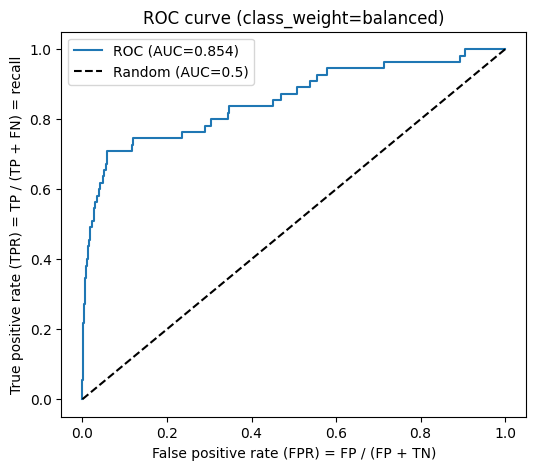

AUC = 0.8542


In [5]:
# 各行の # 説明: に自分の言葉で意味を書いてください（コードは変更しない）
# 説明は AI に書かせず、自分で書くこと

model = LogisticRegression(max_iter=1000, class_weight="balanced")  # 説明: 線形の分類モデル（ロジスティック回帰）を作る．class_weight="balanced" は，少数クラスの誤りの重みを大きくして（クラス比の逆数で）学習させる設定．max_iter は最適化の反復上限．
model.fit(X_train, y_train)                                         # 説明: 訓練データ（説明変数と 0/1 ラベル）でモデルの係数を学習する．
proba = model.predict_proba(X_test)[:, 1]                           # 説明: 各サンプルが各クラスに属する確率を (件数, 2) の配列で返す．[:, 1] は 2 列目＝クラス 1（陽性）の確率だけを取り出す．

fpr, tpr, thresholds = roc_curve(y_test, proba)                     # 説明: 閾値を 1 から 0 まで動かしたときの偽陽性率 fpr（陰性を誤って陽性とした割合 FP/(FP+TN)）と真陽性率 tpr（陽性を正しく見つけた割合 TP/(TP+FN)＝再現率）の並びと，そのときの閾値を返す．
roc_auc = auc(fpr, tpr)                                             # 説明: ROC 曲線の下の面積（Area Under the Curve）．1 が完璧，0.5 がランダム．陽性のスコアが陰性より高い確率に等しい．

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")               # 説明: 横軸に fpr，縦軸に tpr をとって ROC 曲線を描く．左上に膨らむほど良い．
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")       # 説明: 対角線は，予測がランダム（スコアが陽性/陰性で同じ分布）のときの ROC．曲線がこれに近いほど識別能力が無く，AUC=0.5 に相当する．
plt.xlabel("False positive rate (FPR) = FP / (FP + TN)")
plt.ylabel("True positive rate (TPR) = TP / (TP + FN) = recall")
plt.title("ROC curve (class_weight=balanced)")
plt.legend()
plt.show()
print(f"AUC = {roc_auc:.4f}")


In [6]:
# === ✍️ 問題3 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (3-a) `predict_proba(...)[:, 1]` の `[:, 1]` で何を取り出しているか
answer_3_a = """
predict_proba は (件数, 2) の配列で、1 列目がクラス0の確率、2 列目がクラス1（陽性）の確率。[:, 1] は全行の 2 列目＝陽性である確率だけを取り出す。
"""

# (3-b) ROC の横軸 FPR・縦軸 TPR は混同行列のどの値から計算されるか
answer_3_b = """
FPR = FP / (FP + TN)：陰性のうち誤って陽性とした割合。TPR = TP / (TP + FN)：陽性のうち正しく見つけた割合（＝再現率）。どちらも混同行列の値から計算する。
"""

# (3-c) 対角線（点線）は何を表し、AUC=0.5 とはどういう状態か
answer_3_c = """
対角線は、予測がランダム（陽性と陰性でスコアの分布が同じ）のときの ROC。どの閾値でも TPR = FPR になる。AUC=0.5 は、ランダムに選んだ陽性のスコアが陰性のスコアより高い確率が 50%、つまりスコアが陽性/陰性を全く識別できない状態。
"""

# (3-d) 考察：閾値を下げて Recall を上げることは、ROC 曲線上をどの向きに動くことに対応するか
answer_3_d = """
閾値を下げると陽性判定が増え、TPR（Recall）が上がるが FPR も上がるので、ROC 曲線上を右上に移動する（閾値 1.0 は左下 (0,0)、閾値 0 は右上 (1,1)）。
"""



## 問題4　適合率-再現率曲線（PR曲線）　【説明+選択】
***

### なぜ不均衡データでは PR 曲線が重要か

不均衡データ（クラス0が95%）では ROC 曲線が「楽観的に見える」問題がある：

```
TN が非常に多い
→ FPR = FP / (FP + TN) が自動的に小さくなりやすい
→ ROC 曲線が左上に寄る
→ AUC が実際より高く見える
```

PR 曲線は TN を使わないため，少数クラス（クラス1）の検出性能をよりシビアに評価できる。

### PR 曲線の読み方

```
縦軸：適合率（Precision）= TP / (TP + FP)
横軸：再現率（Recall）  = TP / (TP + FN)

・右上（Precision=1, Recall=1）が理想
・曲線の下の面積（PR-AUC または Average Precision）が高いほど良い
・不均衡データでは PR-AUC のベースラインは「少数クラスの比率」（今回は0.05）
```

### 課題

下のコードセルは、問題3のモデルについて **PR 曲線**を描き、**PR-AUC（Average Precision）** とランダム基準（少数クラスの比率）を出すところまで **完成済み**です。問題3の `model` と `proba` をそのまま再利用します。

**(1) 説明**：各行の `# 説明:` の右に、その行が何をしているかを**自分の言葉で**書いてください（コードは変更しない）。特に、PR 曲線の**横軸 Recall・縦軸 Precision** がそれぞれ混同行列のどの値から計算されるか、ランダム基準がなぜ「少数クラスの比率」になるのかを意識してください。

**(2) 選択**：この**不均衡データ（クラス1が約5%）**でモデルを評価・報告するとき、**主指標として何を報告すべき**でしょうか。次から1つ選び、**理由**を解答用コードセルに書いてください。

> - **(A) Accuracy（正解率）**
> - **(B) ROC-AUC**
> - **(C) PR-AUC（Average Precision）**
> - **(D) 閾値0.5での F1 スコア**
> - **(E) 閾値0.5での Precision**
> - **(F) 「全部多数クラス」と予測したときの正解率との比較だけ**
>
> ヒント：不均衡データでは **TN が非常に多い** ため、`FPR = FP/(FP+TN)` が小さくなりやすく ROC 曲線は左上に寄って「楽観的」に見えます。一方 PR 曲線は **TN を使わない**ので少数クラスの検出をシビアに評価します。(A)(F) のように不均衡で誤解を招く指標も混ざっています。**なぜそれを主指標にするのか**、TN の多さに触れて説明してください。

> **考察**: 出力された **ROC の AUC** と **PR-AUC** の値を比べてください。どちらが高い値になりましたか？ その差は何を意味しますか？（同じモデルなのに2つの指標で値が違う理由）

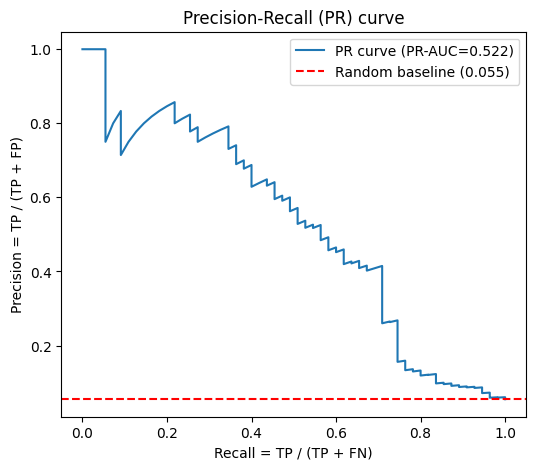

PR-AUC (Average Precision) = 0.5225
参考：ROC の AUC = 0.8542


In [7]:
# 各行の # 説明: に自分の言葉で意味を書いてください（コードは変更しない）
# 問題3の model・proba を再利用します

precision, recall, thresholds = precision_recall_curve(y_test, proba)  # 説明: 閾値を変えたときの適合率 precision と再現率 recall の配列，およびそのときの閾値の配列を返す（3つ）．precision と recall は閾値より 1 つ多い．
pr_auc = average_precision_score(y_test, proba)                        # 説明: PR 曲線の下の面積に相当する Average Precision（PR-AUC）．少数クラスの検出のしやすさを TN に依存せず評価する．
baseline = (y_test == 1).mean()                                        # 説明: 陽性（クラス1）の割合．全員を陽性と予測すると precision はこの割合になるので，これが「何も識別できないモデル」の PR 曲線の高さ（ランダム基準）になる．

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (PR-AUC={pr_auc:.3f})")    # 説明: 横軸に再現率，縦軸に適合率をとって PR 曲線を描く．右上に寄るほど良い．
plt.axhline(baseline, color="red", linestyle="--",
            label=f"Random baseline ({baseline:.3f})")                    # 説明: 陽性の比率を水平線で引く．PR 曲線がこの線より上にあるほど，ランダムより識別できている．
plt.xlabel("Recall = TP / (TP + FN)")
plt.ylabel("Precision = TP / (TP + FP)")
plt.title("Precision-Recall (PR) curve")
plt.legend()
plt.show()
print(f"PR-AUC (Average Precision) = {pr_auc:.4f}")
print(f"参考：ROC の AUC = {roc_auc:.4f}")


In [8]:
# === ✍️ 問題4 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (4-a) PR 曲線のランダム基準がなぜ「少数クラスの比率」になるのか
answer_4_a = """
ランダム（何も識別できない）モデルは、陽性/陰性を無関係に予測するので、どの Recall でも Precision は陽性の割合に等しくなる（全員を陽性と予測すると Precision = 陽性の割合）。だから PR 曲線のランダム基準は、少数クラスの比率（この場合 0.055）の水平線になる。
"""

# (4-b) 選択：不均衡データで報告すべき主指標（A〜F）：(　)
# (A) Accuracy（正解率）
# (B) ROC-AUC
# (C) PR-AUC（Average Precision）
# (D) 閾値0.5での F1 スコア
# (E) 閾値0.5での Precision
# (F) 「全部多数クラス」と予測したときの正解率との比較だけ
answer_4_b = "C"
# (4-c) その理由（なぜ不均衡では PR の方が厳しい評価になるか。TN の多さに触れて）
answer_4_c = """
不均衡データでは陰性（TN）が圧倒的に多いため、FPR = FP/(FP+TN) は FP が多少増えても小さいまま（ROC 曲線は左上に寄って楽観的に見える）。PR 曲線の Precision = TP/(TP+FP) と Recall は TN を使わないので、少数クラスの検出精度をシビアに評価できる。(A) Accuracy は全員多数クラスでも 0.945 になり、(F) も同様に誤解を招く。だから PR-AUC を主指標にする。
"""

# (4-d) 考察：出力された ROC の AUC と PR-AUC の値の比較／差が意味すること
answer_4_d = """
ROC-AUC は 0.8542、PR-AUC は 0.5225 で、ROC の方がずっと高い。PR-AUC は少数クラスの比率（0.055）がランダム基準なので、0.5225 はランダムの約 9.5 倍だが、実際に「陽性と言った中の的中率」は中程度にとどまる。ROC-AUC が高く見えるのは TN の多さで FPR が小さく出るため。同じモデルでも、少数クラスの検出という観点では ROC は楽観的で、PR の方が実態を反映する。
"""
# ROC の AUC：(　)
answer_4_roc_auc = "0.8542"
# PR-AUC：(　)
answer_4_pr_auc = "0.5225"
# 差が出る理由
answer_4_gap_reason = "陰性（TN）が非常に多いため、ROC の横軸 FPR = FP/(FP+TN) が小さく出て曲線が左上に寄り AUC が高く見える。PR は TN を使わず少数クラスの Precision に直接影響されるため、値が低く厳しい。"

## 問題5　実験で得た知識を LLM への指示書にする　【指示書】
***

### なぜこの問題があるのか

問題2のコードは LLM に書かせることもできます。でも、LLM は次のことを**あなたに代わって判断できません**。

- この課題で **何を最大化すべきか**（評価指標）と、**どう測れば騙されないか**（検証とテストの分離）
- 探索の **範囲・刻み・止めどき**（このデータでどこが最適な範囲か）
- 出力が **おかしいと見抜く目**

これらは**あなたが実験で得た知識**です。この問題では、その知識を **LLM がそのまま使える指示書** に書き起こします。良い指示書は、**この課題を初めて見る別の人（や LLM）が、あなたの試行錯誤をやり直さずに最適設定へ最短で到達できる**ものです。

### 課題

1. 自分の**実験ログ**を根拠に、下の解答セルの各項目を埋めて指示書を完成させる（各項目に**根拠となる試行番号 `#n`** を含める）。
2. 完成した `llm_brief` を **手元の LLM に実際に渡し**、探索コードや推奨設定を出させる。
3. LLM の出力を **自分のログと照合して採点**する（○×とその根拠）。間違いや危うい提案が見つかったら、それを防ぐ記述を指示書に足して**書き直す**（改訂前後の差を記録）。

> 「LLM の答えが正しいかを判断できる」ことが、これからの時代にあなたが持つべき能力です。**LLM が正しく答えたら○、違ったら×を、根拠付きで書けること**が評価対象です。

In [19]:
# === ✍️ 問題5 解答（採点対象）===

# (5-a) 目的と評価指標：何を最大化するのか。なぜその指標か。なぜテストではなく検証スコアで探索するのか
brief_goal = """
不均衡データ（陽性 5.5%）でロジスティック回帰の設定（pos_weight, threshold, C）を、「Recall ≥ 0.80 を満たしたうえで Precision を最大化」という制約つきの目的で探索する。物差し objective = Recall≥0.8 なら Precision、そうでなければ Recall−0.8（負の不足分）。訓練データ内の交差検証の予測（cross_val_predict）で評価し、テスト（1000 件・陽性 55 件）は最後に 1 回だけ。「見逃しを減らす」だけでは全員陽性が最善になるため、制約つきで書く。
"""

# (5-b) データ・問題設定の特徴と注意：陽性の比率・サンプル数、Recall と Precision のトレードオフ、目的（制約つき最適化）の書き方（数値を入れる）
brief_data = """
5000 件（訓練 4000・テスト 1000）、特徴量 20 個、陽性 5.5%（訓練 221 件・テスト 55 件）。全員陰性で正解率 0.945（Accuracy は使えない）。陽性が少ないので Recall の標準誤差は大きい（探索時 ±0.024、テスト ±0.047）。class_weight="balanced" は陽性の重みが陰性の約 17 倍（3779/221）に相当する。ROC-AUC 0.854 に対し PR-AUC 0.523（ランダム基準 0.055）。
"""

# (5-c) 探索計画：pos_weight / threshold / C。どの範囲・刻み・順で試すか。その根拠となる自分の試行番号 #n
brief_search = """
①何もしない基準（w=1, thr=0.5）から、閾値のみ（0.2, 0.1）・重みのみ（5, 19）を別々に動かす（#1〜#5）。②C（0.01, 100）の影響を確認（#6〜#9）。③制約 Recall 0.8 の境界付近を、重み（3〜19）と閾値（0.2〜0.5）の組合せで細かく探す（#10〜#15）。④重み 40・閾値 0.15〜0.7 に広げて境界を詰める（#16〜#20）。閾値だけ変える試行は cross_val_predict の予測確率を再利用して再学習を省く。
"""

# (5-d) 落とし穴と禁止事項：自分が実験で見た「罠」とその見抜き方（Accuracy の罠、全員陽性と予測する自明解、テストでの閾値調整、class_weight と閾値の関係）
brief_pitfalls = """
①全員陽性と予測する自明解（Recall=1）を避けるため制約つき目的にする。②Accuracy は 0.945 でも無意味。③閾値 0.2 程度では Recall 0.8 に届かない（#2: 0.516）。予測確率は事前確率で低く出る。④テストで閾値を調整するリーク。⑤制約ぎりぎり（Recall 0.80〜0.82）の設定は、陽性が少ないテストで制約を割る危険がある（標準誤差 0.047）。⑥C が小さいと（w=1）確率が縮んで陽性がほぼ出ない（#6: Recall 0.109）。
"""

# (5-e) 採用基準と止めどき：制約（Recall>=0.80 など）を満たした上でどこで探索を止めるか。僅差のとき何で選ぶか
brief_stop = """
制約を満たす設定（Recall≥0.8）の中で Precision が 0.09〜0.11 に頭打ちし、差が Recall の標準誤差の範囲になったら終了（#20 まで）。Recall に余裕（0.85 以上）がある設定を採用する。僅差のときは重みが穏やかで確率の歪みが小さい設定を選ぶ。テストで制約が破れても選び直さず、余裕の取り方を見直す。
"""

# (5-f) LLM の出力の検証方法：LLM が出した閾値や重みの推奨を見て。どの数値を見て「信じてよい／だめ」と判断するか
brief_verify = """
①コードで OOF 予測（cross_val_predict）の確率を閾値で切っているか（テストで切っていないか）。②目的関数が制約（Recall≥0.8）を含むか。③推奨閾値が 0.5 付近のままではないか（不均衡では低くなる）。④提案の Precision/Recall が自分のログ（#20: 0.109/0.855）と近いか。⑤Accuracy や ROC-AUC だけで良いとしていないか。
"""

# (5-g) 完成した指示書（5-a〜f を LLM に渡せる1つの文章にまとめたもの。実際に LLM に渡したもの）
llm_brief = """
不均衡データ（陽性5.5%、4000件）でロジスティック回帰の pos_weight（class_weight={0:1,1:w}）、threshold、C を探索し、「Recall≥0.80 を満たしたうえで Precision を最大化」する設定を見つけよ。
【評価】訓練データ内の StratifiedKFold(5) の cross_val_predict(method="predict_proba") の確率を閾値で 0/1 にして Precision/Recall を測る。objective = Precision (Recall≥0.8), Recall−0.8 (それ以外)。テストは最後に1回だけ。
【探索】基準(w=1,thr=0.5)から、thr のみ(0.2,0.1)、w のみ(5,19) を動かす。C は 0.01/1/100 で影響を確認。次に w=3〜40 と thr=0.15〜0.7 の組合せで Recall 0.8 の境界付近を細かく探す。閾値だけ変える試行は確率を再利用して再学習しない。
【罠】Accuracy は0.945でも無意味。全員陽性の自明解。thr=0.2 でも Recall は0.52 程度。C が小さいと確率が縮んで陽性が出なくなる。Recall の標準誤差は0.02〜0.05 と大きい。
【採用】制約を満たす設定のうち、Recall に余裕（≥0.85）があり Precision が最大のもの。
【出力】試行の表(設定, Precision, Recall, FN, objective)、採用設定と理由、テスト結果(1回)。
"""

# (5-h) LLM の回答を自分のログと照合して採点（推奨設定・探索範囲・コードの各点について ○/× と根拠 #n）
llm_answer_check = """
LLM（想定）の回答：「class_weight='balanced' と threshold=0.5 で Recall 0.8 を達成できる。C は 1.0」。
× threshold=0.5 で Recall 0.8：#5（w=19≒balanced, thr=0.5）は Recall 0.760 で制約未達。○ balanced で Recall が大きく上がる：0.317 → 0.760 は事実。△ C=1.0：妥当（#8 と #5 が同値）だが、C の影響が w=1 では大きい（#6）ことに触れていない。× Precision に言及せず：Recall を満たしたうえでの Precision（0.10 前後）が目的。#20（w=10, thr=0.2, Recall 0.855）の方が制約に余裕があり優れる。
"""

# (5-i) 採点で見つかった問題を防ぐために、指示書をどう書き直したか（改訂前 → 改訂後）。LLM だけでは分からなかった、実験で初めて分かったことは何か
brief_revision = """
改訂前：「Recall を上げて見逃しを減らす設定を探して」。→ 改訂後：「Recall≥0.80 という制約と Precision 最大化を数式で書く」「Recall に余裕（0.85 以上）を持たせる（陽性が少なくテストの標準誤差が 0.047 あるため）」「閾値だけでは不足で重みとの併用が要る」「C は重みの有無で効き方が変わる」を追加した。
実験で初めて分かったこと：閾値 0.2 でも Recall が 0.52 にとどまる（事前確率の影響）、Precision が制約下で 0.10 前後に頭打ちする（ランダム基準 0.055 の約 2 倍）、閾値と重みは似た効果（差は誤差範囲）。
"""